In [ ]:
generate corrolated embeddings,
inverse of the covariance,
add 1 randomly on off diagonal. 
https://stats.stackexchange.com/questions/587800/creating-a-random-sparse-precision-matrix

# approach 1
https://stats.stackexchange.com/questions/215497/how-to-create-an-arbitrary-covariance-matrix/215505#215505
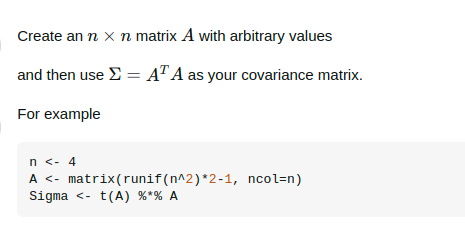

problem: Might not be semidefinite

problem: How to make sparse? Even sparse A does not imply sparse $\Sigma$

In [192]:
import numpy as np
import scipy.sparse as sp
from scipy.linalg import cholesky
from scipy.stats import norm

def density_of_numpy(A):
    nnz = np.count_nonzero(A)
    shape = np.shape(A)
    return nnz/(shape[0]*shape[1])
# arguments:
V = 200
# ---
density = np.log(V)/V
A = sp.random(V, V, density=density, data_rvs=norm(loc=0, scale=100).rvs)

lambda_reg = 1e-0
Q = A.transpose().dot(A) # precision
print(f"Density of A: {A.nnz/(V**2):.4f}")
print(f"Density of Q: {Q.nnz/(V**2):.4f}")
Q = Q + lambda_reg * np.eye(V)
print(f"Density of Q: {density_of_numpy(Q)}") # check if works.

try:
    cholesky_factor = cholesky(Q, lower=True)
    print("Positive definite.")
    is_positive_definite =True
except:
    print("NOT Positive definite.")
    is_positive_definite = False

if is_positive_definite:
    Sigma = np.linalg.inv(Q)
    print(f"Density of Sigma=inverse(Q): {density_of_numpy(Sigma):.4f}")

Sigma

Density of A: 0.0265
Density of Q: 0.1348
Density of Q: 0.1349
Positive definite.
Density of Sigma=inverse(Q): 0.9801


matrix([[ 0.00076155,  0.00098263, -0.00077393, ...,  0.00011942,
          0.0011561 ,  0.00063213],
        [ 0.00098263,  0.00521909, -0.00568014, ...,  0.0033494 ,
         -0.00047384, -0.00127384],
        [-0.00077393, -0.00568014,  0.01560109, ...,  0.00275314,
         -0.00126887, -0.00034215],
        ...,
        [ 0.00011942,  0.0033494 ,  0.00275314, ...,  0.01581976,
         -0.0037782 , -0.00326332],
        [ 0.0011561 , -0.00047384, -0.00126887, ..., -0.0037782 ,
          0.00788118,  0.00339125],
        [ 0.00063213, -0.00127384, -0.00034215, ..., -0.00326332,
          0.00339125,  0.00628454]])

(-1.0, 1.0)

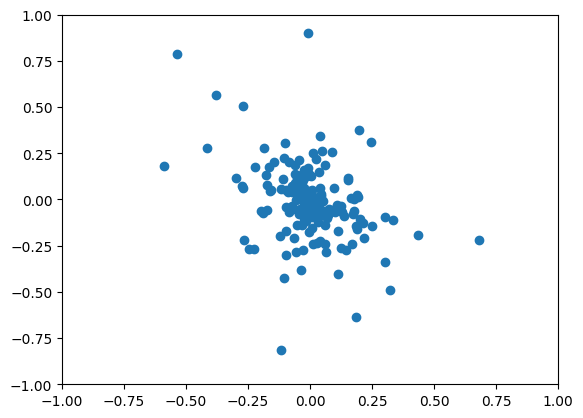

In [193]:
import matplotlib.pyplot as plt

X = np.random.multivariate_normal( np.zeros(V), Sigma, size=2)

plt.scatter(X[0], X[1])
plt.xlim([-1, 1])
plt.ylim([-1, 1])

In [200]:
len(np.sqrt(np.sum(X**2, axis=0)))

200

In [195]:
X.apply(lambda x: np.sqrt(x**2), axis=1)

AttributeError: 'numpy.ndarray' object has no attribute 'apply'

In [223]:
# Make into a function

import numpy as np
import scipy.sparse as sp
from scipy.linalg import cholesky
from scipy.stats import norm


def generate_correlated_covariance(V, normalize_Sigma=True, K=10):
    """
    Generate sparse matrix A, density = log(V)/V
    Create precision matrix, Q =  A^T A, which is sparse as well.
    Compute Sigma = inverse(Q), which is now dense.

    Empirically we get that as V increases density of V -> 1.0, Q -> 0.0

    Sigma is normalized using a simulation based approach: 
        sample 1k from the prior and divide with the average |rho_v| in that sample
    """
    def density_of_numpy(A):
        nnz = np.count_nonzero(A)
        shape = np.shape(A)
        return nnz/(shape[0]*shape[1])
    
    density = np.log(V)/V
    A = sp.random(V, V, density=density, data_rvs=norm(loc=0, scale=100).rvs)

    lambda_reg = 1e-0
    Q = A.transpose().dot(A) # precision
    print(f"Density of A: {A.nnz/(V**2):.4f}")
    print(f"Density of Q: {Q.nnz/(V**2):.4f}")
    Q = Q + lambda_reg * np.eye(V)

    try:
        cholesky(Q, lower=True)
        is_positive_definite =True
    except:
        is_positive_definite = False

    assert is_positive_definite, 'Abort: Precision matrix is not pos definite.'

    if is_positive_definite:
        Sigma = np.linalg.inv(Q)
        print(f"Density of Sigma=inverse(Q): {density_of_numpy(Sigma):.4f}")


    if normalize_Sigma:
        theta_unormalized = sample_correlated_theta(Sigma, K, 1000)
        avg_euclidean_norm_sq = np.mean(  np.sum(theta_unormalized**2, axis=0))
        print(avg_euclidean_norm_sq)
        Sigma = Sigma/avg_euclidean_norm_sq

        # test
        theta_unormalized = sample_correlated_theta(Sigma, K, 1000)
        avg_euclidean_norm = np.sqrt( np.mean(  np.sum(theta_unormalized**2, axis=0)) ) 
        print(avg_euclidean_norm)

    return Sigma

def sample_correlated_theta(Sigma, K, N=None):

    V = np.shape(Sigma)[0]
    if N is None:
        theta = np.random.multivariate_normal( np.zeros(V), Sigma, size=(2*V, K))
    else:
        theta = np.random.multivariate_normal( np.zeros(V), Sigma, size=(N, K))

    return theta
    

generate_correlated_covariance(100, K=5)


Density of A: 0.0461
Density of Q: 0.1952
Density of Sigma=inverse(Q): 1.0000
38.312341292225625
1.0044224430070865


matrix([[ 3.58605838e-06,  6.17526647e-07, -1.13894742e-06, ...,
         -1.50295694e-06,  1.28025056e-06,  6.34588413e-07],
        [ 6.17526647e-07,  9.21603270e-06,  5.49641251e-06, ...,
          6.51615219e-06, -3.44637309e-06,  2.68085848e-05],
        [-1.13894742e-06,  5.49641251e-06,  8.00205046e-05, ...,
         -3.24163866e-05,  1.60938571e-05, -7.56396010e-05],
        ...,
        [-1.50295694e-06,  6.51615219e-06, -3.24163866e-05, ...,
          2.26513411e-04, -7.20423644e-05,  2.20496881e-04],
        [ 1.28025056e-06, -3.44637309e-06,  1.60938571e-05, ...,
         -7.20423644e-05,  3.17057182e-05, -9.07271459e-05],
        [ 6.34588413e-07,  2.68085848e-05, -7.56396010e-05, ...,
          2.20496881e-04, -9.07271459e-05,  1.01293519e-03]])

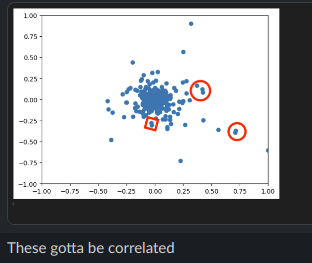